In [129]:
import pandas as pd
import numpy as np
import os
from pandas.plotting import scatter_matrix
from matplotlib import pyplot
import scipy as sp
import holidays
from collections import deque
from lightgbm import LGBMRegressor
import joblib

In [130]:
path = "../dataset/household_power_consumption.csv"

df = pd.read_csv(path, sep=';', low_memory=False)

# Análise Exploratória

In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    str    
 3   Global_reactive_power  str    
 4   Voltage                str    
 5   Global_intensity       str    
 6   Sub_metering_1         str    
 7   Sub_metering_2         str    
 8   Sub_metering_3         float64
dtypes: float64(1), str(8)
memory usage: 142.5 MB


Os dados se encontram no formato de string, logo seleciono as colunas e trato-as para formato numérico.

In [132]:
cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2'
]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

In [133]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 142.5 MB


In [134]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [135]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Removendo variáveis

In [136]:
df = df.drop(columns=['Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'])

In [137]:
df = df.dropna()

In [155]:
df.isnull().sum()

Date                   0
Time                   0
Global_active_power    0
dtype: int64

In [139]:
amostra = df.sample(n=1000, random_state=42)

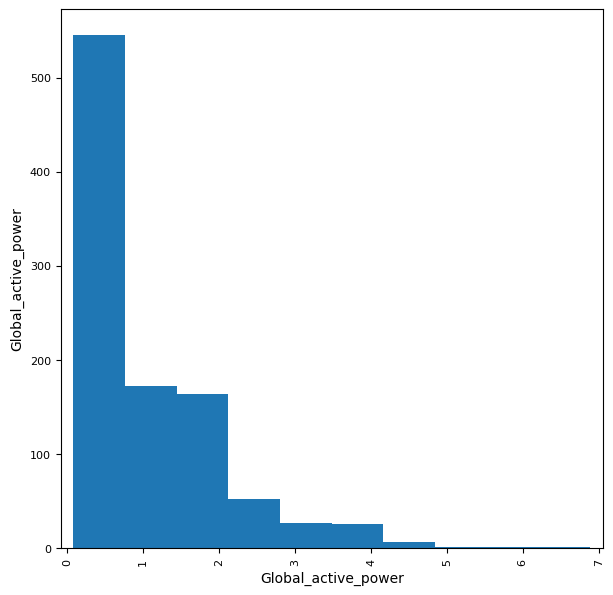

In [140]:
df_without_timestamp = amostra.drop(columns=["Date", "Time"])
scatter_matrix(df_without_timestamp, figsize=(7,7))
pyplot.show()   

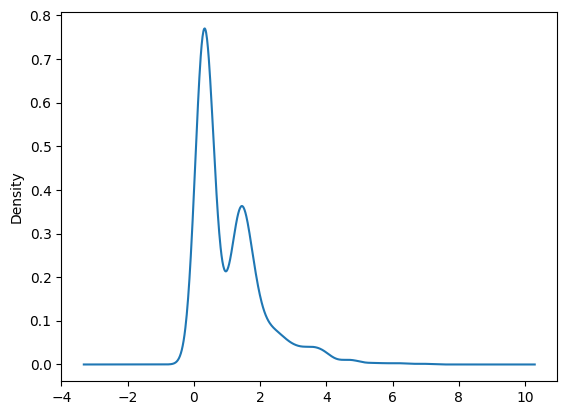

In [141]:
amostra['Global_active_power'].plot(kind='kde')
# amostra.plot.scatter(x='use', y='dataid', colormap='viridis')
pyplot.show()


## Agrupando por data

In [142]:
df_transformated = df.copy()
# df_aggregated = df.sample(100000)
# df_aggregated = df[0:5000000]

### Convertee date e time para formato timestamp

In [143]:
aggregate_freq = "1D"

In [144]:
# juntar data + hora
df_transformated["datetime"] = (
    pd.to_datetime(
        df_transformated["Date"] + " " + df_transformated["Time"],
        format="%d/%m/%Y %H:%M:%S"
    )
    .dt.tz_localize(
        "Europe/Paris",
        ambiguous="NaT",
        nonexistent="shift_forward"
    )
)
# converter para UTC
df_transformated = df_transformated.dropna(subset=["datetime"])

df_transformated = df_transformated.drop(columns=['Date', 'Time'])

In [145]:
df_transformated.head()

,Global_active_power,datetime
0,4.216,2006-12-16 17:24:00+01:00
1,5.360,2006-12-16 17:25:00+01:00
2,5.374,2006-12-16 17:26:00+01:00
3,5.388,2006-12-16 17:27:00+01:00
4,3.666,2006-12-16 17:28:00+01:00


## Testando biblioteca de feriados

In [146]:
fr_holidays = holidays.FR()

In [147]:
"2025-01-01" in fr_holidays
fr_holidays.get("2025-01-01")

"New Year's Day"

In [148]:
df_transformated.iloc[0]["datetime"]

Timestamp('2006-12-16 17:24:00+0100', tz='Europe/Paris')

In [149]:
df_transformated.head()

,Global_active_power,datetime
0,4.216,2006-12-16 17:24:00+01:00
1,5.360,2006-12-16 17:25:00+01:00
2,5.374,2006-12-16 17:26:00+01:00
3,5.388,2006-12-16 17:27:00+01:00
4,3.666,2006-12-16 17:28:00+01:00


## Gerando as features

In [156]:
features = [
    "today",
    "lag_1",
    "lag_2",
    "lag_3",

    "lag_7",
    "lag_14",
    "lag_30",

    "rolling_mean_7",
    "rolling_mean_30",
    "rolling_std_7",

    "day_of_week",
    "month",
    "is_weekend",
    "is_holiday",

    "date"

    # "days_since_start",
    # "valid_lags"
]

newdf = pd.DataFrame(columns=features)

In [151]:
df_transformated.head()

,Global_active_power,datetime
0,4.216,2006-12-16 17:24:00+01:00
1,5.360,2006-12-16 17:25:00+01:00
2,5.374,2006-12-16 17:26:00+01:00
3,5.388,2006-12-16 17:27:00+01:00
4,3.666,2006-12-16 17:28:00+01:00


In [ ]:

df_transformated["datetime"] = pd.to_datetime(df_transformated["datetime"])

df_transformated = df_transformated.set_index("datetime")

# Revisar valores em branco
df_transformated["energy_kwh"] = (
    df_transformated["Global_active_power"] / 60
)

df_daily = (
    df_transformated
    .resample("D")["energy_kwh"]
    .sum()
    .to_frame()
)

In [153]:
df_daily.head()

,energy_kwh
datetime,
2006-12-16 00:00:00+01:00,20.152933
2006-12-17 00:00:00+01:00,56.507667
2006-12-18 00:00:00+01:00,36.730433
2006-12-19 00:00:00+01:00,27.769900
2006-12-20 00:00:00+01:00,37.095800


In [160]:

lags = np.full(6, np.nan)
rolling_mean_7 = np.nan
rolling_mean_30 = np.nan
rolling_std_7 = np.nan
days_since_start = 0
valid_tags = 1
last_30_values = deque(([np.nan] * 30), maxlen=30)
Y = None

day_of_week = None
month = None
is_weekend = None

# Pega o primeiro elemento e o remove do grupo
first = df_daily.iloc[0]
grupo = df_daily.iloc[1:]
print(grupo.iloc[0])

last_30_values.append(first.energy_kwh)
lags[0] = first.energy_kwh # Dia anterior

for localminute, row in grupo.iterrows():
    lags[1] = last_30_values[28] # Dia -2
    lags[2] = last_30_values[27] # Dia -3
    lags[3] = last_30_values[26] # Dia -7
    lags[4] = last_30_values[23] # Dia -14
    lags[5] = last_30_values[0] # Dia -30

    rolling_mean_7 = np.mean(list(last_30_values)[-7:])
    rolling_mean_30 = np.mean(last_30_values)
    rolling_std_7 = np.std(list(last_30_values)[-7:])

    days_since_start += 1

    valid_tags = np.sum(~np.isnan(lags))

    day_of_week = localminute.dayofweek
    month = localminute.month
    is_weekend = day_of_week >= 5
    is_holiday = localminute in fr_holidays


    newdf.loc[len(newdf)] = {
        "today": row['energy_kwh'],
        "lag_1": lags[0],
        "lag_2": lags[1],
        "lag_3": lags[2],
        "lag_7": lags[3],
        "lag_14": lags[4],
        "lag_30": lags[5],
        "rolling_mean_7": rolling_mean_7,
        "rolling_mean_30": rolling_mean_30,
        "rolling_std_7": rolling_std_7,
        "day_of_week": day_of_week,
        "month": month,
        "is_weekend": is_weekend,
        "date": localminute.to_pydatetime(),
        "is_holiday": is_holiday
    }

    last_30_values.append(row['energy_kwh'])
    Y = row['energy_kwh']
    print(lags)
    lags[0] = row['energy_kwh']

energy_kwh    56.507667
Name: 2006-12-17 00:00:00+01:00, dtype: float64
[20.15293333         nan         nan         nan         nan         nan]
[56.50766667 20.15293333         nan         nan         nan         nan]
[36.73043333 56.50766667 20.15293333         nan         nan         nan]
[27.7699     36.73043333 56.50766667 20.15293333         nan         nan]
[37.0958     27.7699     36.73043333 56.50766667         nan         nan]
[28.6104     37.0958     27.7699     36.73043333         nan         nan]
[39.0223     28.6104     37.0958     27.7699     20.15293333         nan]
[79.55643333 39.0223     28.6104     37.0958     56.50766667         nan]
[42.5002     79.55643333 39.0223     28.6104     36.73043333         nan]
[45.71866667 42.5002     79.55643333 39.0223     27.7699             nan]
[65.5685     45.71866667 42.5002     79.55643333 37.0958             nan]
[25.47933333 65.5685     45.71866667 42.5002     28.6104             nan]
[34.54396667 25.47933333 65.5685     45.

In [161]:
df_daily.head(8)

,energy_kwh
datetime,
2006-12-16 00:00:00+01:00,20.152933
2006-12-17 00:00:00+01:00,56.507667
2006-12-18 00:00:00+01:00,36.730433
2006-12-19 00:00:00+01:00,27.769900
2006-12-20 00:00:00+01:00,37.095800
2006-12-21 00:00:00+01:00,28.610400
2006-12-22 00:00:00+01:00,39.022300
2006-12-23 00:00:00+01:00,79.556433


In [164]:
newdf = newdf.dropna()
newdf

,today,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,day_of_week,month,is_weekend,is_holiday,date
29,35.811300,50.130267,53.113567,24.354933,37.586567,37.356000,20.152933,38.515081,40.528158,9.348369,0,1,False,False,2007-01-15 00:00:00+01:00
30,28.106733,35.811300,50.130267,53.113567,24.354933,31.150900,56.507667,38.294410,41.050103,9.391258,1,1,False,False,2007-01-16 00:00:00+01:00
31,47.461467,28.106733,35.811300,50.130267,53.113567,35.913333,36.730433,37.859529,40.103406,9.774641,2,1,False,False,2007-01-17 00:00:00+01:00
32,30.357700,47.461467,28.106733,35.811300,50.130267,37.586567,27.769900,39.509262,40.461107,10.268978,3,1,False,False,2007-01-18 00:00:00+01:00
33,24.674000,30.357700,47.461467,28.106733,35.811300,24.354933,37.095800,38.476567,40.547367,10.762053,4,1,False,False,2007-01-19 00:00:00+01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,34.025600,15.015167,36.616767,26.173333,27.535867,29.123033,38.220600,26.570548,28.071190,5.904988,0,11,False,False,2010-11-22 00:00:00+01:00
1437,26.292267,34.025600,15.015167,36.616767,26.173333,25.162467,39.842467,27.270914,27.931357,6.433298,1,11,False,False,2010-11-23 00:00:00+01:00
1438,29.937467,26.292267,34.025600,15.015167,36.616767,26.367200,19.388200,27.432314,27.479683,6.392418,2,11,False,False,2010-11-24 00:00:00+01:00
1439,23.852733,29.937467,26.292267,34.025600,15.015167,27.535867,15.765067,27.942352,27.831326,6.429413,3,11,False,False,2010-11-25 00:00:00+01:00


In [171]:
newdf.head(8)

,today,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,day_of_week,month,is_weekend,is_holiday,date
29,35.811300,50.130267,53.113567,24.354933,37.586567,37.356000,20.152933,38.515081,40.528158,9.348369,0,1,False,False,2007-01-15 00:00:00+01:00
30,28.106733,35.811300,50.130267,53.113567,24.354933,31.150900,56.507667,38.294410,41.050103,9.391258,1,1,False,False,2007-01-16 00:00:00+01:00
31,47.461467,28.106733,35.811300,50.130267,53.113567,35.913333,36.730433,37.859529,40.103406,9.774641,2,1,False,False,2007-01-17 00:00:00+01:00
32,30.357700,47.461467,28.106733,35.811300,50.130267,37.586567,27.769900,39.509262,40.461107,10.268978,3,1,False,False,2007-01-18 00:00:00+01:00
33,24.674000,30.357700,47.461467,28.106733,35.811300,24.354933,37.095800,38.476567,40.547367,10.762053,4,1,False,False,2007-01-19 00:00:00+01:00
34,52.228867,24.674000,30.357700,47.461467,28.106733,53.113567,28.610400,38.522148,40.133307,10.702659,5,1,True,False,2007-01-20 00:00:00+01:00
35,56.787700,52.228867,24.674000,30.357700,47.461467,50.130267,39.022300,38.395762,40.920589,10.533492,6,1,True,False,2007-01-21 00:00:00+01:00
36,36.341567,56.787700,52.228867,24.674000,30.357700,35.811300,79.556433,39.346824,41.512769,11.777183,0,1,False,False,2007-01-22 00:00:00+01:00


In [172]:
newdf = newdf.sort_values(by="date")

In [176]:
train = newdf[newdf["date"] < "2009-01-01"]

val = newdf[
    (newdf["date"] >= "2009-01-01") &
    (newdf["date"] < "2010-01-01")
]

test = newdf[newdf["date"] >= "2010-01-01"]

In [177]:
train.shape, val.shape, test.shape

((717, 15), (365, 15), (330, 15))

In [178]:
X_train = train.drop(columns=["today", "date"])
y_train = train["today"]

X_val = val.drop(columns=["today", "date"])
y_val = val["today"]

X_test = test.drop(columns=["today", "date"])
y_test = test["today"]

In [179]:
X_train.head()

,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,day_of_week,month,is_weekend,is_holiday
29,50.130267,53.113567,24.354933,37.586567,37.356000,20.152933,38.515081,40.528158,9.348369,0,1,False,False
30,35.811300,50.130267,53.113567,24.354933,31.150900,56.507667,38.294410,41.050103,9.391258,1,1,False,False
31,28.106733,35.811300,50.130267,53.113567,35.913333,36.730433,37.859529,40.103406,9.774641,2,1,False,False
32,47.461467,28.106733,35.811300,50.130267,37.586567,27.769900,39.509262,40.461107,10.268978,3,1,False,False
33,30.357700,47.461467,28.106733,35.811300,24.354933,37.095800,38.476567,40.547367,10.762053,4,1,False,False


In [180]:
y_train.head()

29    35.811300
30    28.106733
31    47.461467
32    30.357700
33    24.674000
Name: today, dtype: float64

In [181]:
model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000228 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2176
[LightGBM] [Info] Number of data points in the train set: 717, number of used features: 12
[LightGBM] [Info] Start training from score 25.950561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [182]:
preds = model.predict(X_test)

In [183]:
print(preds)

[26.17995674 27.2326692  36.20390873 28.41479143 26.33729976 28.63056205
 21.15617375 26.47899146 26.215588   32.95697841 27.08999706 31.72393336
 25.8000685   8.58678388 10.16864881 27.87843286 23.53500222 22.15946623
 24.68986191 25.20358278 27.12921826 29.06623733 40.71194174 36.97061572
 28.34354485 30.95562932 31.34508302 29.24021346 25.82383961 35.3493127
 41.34229046 28.05641253 35.20984657 27.99254277 28.78138675 30.43196143
 32.89169166 37.9930942  25.03332606 32.9525907  30.21271185 30.63346748
 34.99145634 43.0562698  38.97876328 28.88384976 41.51890177 33.72372605
 35.13111985 29.86458697 38.91198466 35.42152886 39.85486173 29.47668474
 35.57730646 27.22640904 30.18396954 41.28810498 30.87354327  8.61529052
 16.95782078 15.9022206  13.72454944 17.05492749 16.33456458 23.1299269
 25.65335815 32.19409715 23.12054    25.88573286 31.47807242 30.44481902
 37.96693645 25.76369608 38.23524003 27.55805809 31.21400669 28.69537336
 36.20159094 14.47164578 17.94049766 30.05008253 23.5

In [184]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

print(rmse)

7.328638588781822


In [185]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    preds
)

print(mae)

5.420989847944342


In [186]:
from sklearn.metrics import mean_absolute_percentage_error

mask = y_test > 0.1

mape = mean_absolute_percentage_error(
    y_test[mask],
    preds[mask]
)
mape

0.3265413438703716